**Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import trange
import os
import random


**Parameters for data preprocessing**

In [2]:
# Number of file to pick in both training and development set
num_files_to_pick = 10000

### Filepaths MFCC ###
# Training
data_dir = 'C:/Users/felip/teamlab-phonetics/feature_extraction/mfcc_segment_outputs/mfcc_training'

# Development/Validation
dev_data_dir = 'C:/Users/felip/teamlab-phonetics/feature_extraction/mfcc_segment_outputs/mfcc_dev'


**Preprocessing of training data** 

In [3]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(data_dir, selected_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
features_list = []
labels_list = []

# Load the features and labels for the selected .pt files
for file_name in selected_files:
    file_path = os.path.join(data_dir, file_name)
    feature, label = torch.load(file_path)
    features_list.append(feature)  # Append the tensors
    labels_list.append(label) # Append the labels

# Concatenate all the data into a single tensor
features = torch.stack(features_list)
print("Example of the features",features[1])
labels = torch.tensor(labels_list)
print("Example of the labels",labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# Create a TensorDataset and DataLoader
dataset = TensorDataset(features, labels)
dataLoader = DataLoader(dataset, batch_size=32, shuffle=True)
print("The training dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-9.0503e+02, -9.0409e+02, -9.0357e+02,  ..., -9.0374e+02,
         -9.0389e+02, -9.0420e+02],
        [ 8.8353e-02,  1.4179e+00,  2.1522e+00,  ...,  1.9144e+00,
          1.7081e+00,  1.2696e+00],
        [ 8.7854e-02,  1.4065e+00,  2.1347e+00,  ...,  1.8981e+00,
          1.6943e+00,  1.2593e+00],
        ...,
        [-5.6992e-02, -1.1335e+00, -1.7384e+00,  ..., -1.5977e+00,
         -1.3751e+00, -1.0212e+00],
        [-6.1038e-02, -1.1662e+00, -1.7855e+00,  ..., -1.6320e+00,
         -1.4131e+00, -1.0496e+00],
        [-6.4855e-02, -1.1924e+00, -1.8223e+00,  ..., -1.6565e+00,
         -1.4431e+00, -1.0720e+00]])
Example of the features tensor([[-8.8507e+02, -8.7619e+02, -8.7238e+02,  ..., -8.7316e+02,
         -8.7277e+02, -8.8220e+02],
        [ 2.6387e+01,  3.8144e+01,  4.3044e+01,  ...,  4.1217e+01,
          4.2082e+01,  3.0296e+01],
        [ 2.1017e+01,  3.0562e+01,  3.4175e+01,  ...,  3.0607e+01,
          3.2181e+01,  2.4451e+01],
        ...

**Dataset inspection**

In [4]:
# Inspect the range of labels in the dataset
#print("Minimum label value:", labels.min().item())
#print("Maximum label value:", labels.max().item())
#print("Unique label values:", torch.unique(labels))

# Inspect the first sample in the batch
print("First sample shape:", features[0].shape)
print("First sample values:\n", features[0])


# Inspect the concatenated tensor
#print("Data Tensor Shape:", data_tensor.shape)
#print("Data Tensor Data Type:", data_tensor.dtype)
#print("Sample Data Tensor Values:\n", data_tensor[:5])  # Print the first 5 rows

# Inspect features and labels
#print("Features Shape:", features.shape)
#print("Labels Shape:", labels.shape)
#print("Sample Features:\n", features[:5])  # Print the first 5 rows of features
print("Sample Labels:\n", labels[:100])  # Print the first 5 labels

First sample shape: torch.Size([40, 126])
First sample values:
 tensor([[-9.0503e+02, -9.0409e+02, -9.0357e+02,  ..., -9.0374e+02,
         -9.0389e+02, -9.0420e+02],
        [ 8.8353e-02,  1.4179e+00,  2.1522e+00,  ...,  1.9144e+00,
          1.7081e+00,  1.2696e+00],
        [ 8.7854e-02,  1.4065e+00,  2.1347e+00,  ...,  1.8981e+00,
          1.6943e+00,  1.2593e+00],
        ...,
        [-5.6992e-02, -1.1335e+00, -1.7384e+00,  ..., -1.5977e+00,
         -1.3751e+00, -1.0212e+00],
        [-6.1038e-02, -1.1662e+00, -1.7855e+00,  ..., -1.6320e+00,
         -1.4131e+00, -1.0496e+00],
        [-6.4855e-02, -1.1924e+00, -1.8223e+00,  ..., -1.6565e+00,
         -1.4431e+00, -1.0720e+00]])
Sample Labels:
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

**Testing the Data Loader**

In [5]:
print(len(dataset[0][0]))
print(features.shape)

for batch in dataLoader:
    features, labels = batch
    print("Batch features shape:", features.shape)
    break

40
torch.Size([10000, 40, 126])
Batch features shape: torch.Size([32, 40, 126])


**Preprocessing and loading the Development/Validation Set**

In [6]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(dev_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(dev_data_dir, selected_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
dev_features_list = []
dev_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in selected_files:
    file_path = os.path.join(dev_data_dir, file_name)
    dev_feature, dev_label = torch.load(file_path)
    dev_features_list.append(dev_feature)  # Append the tensors
    dev_labels_list.append(dev_label) # Append the labels

# Concatenate all the data into a single tensor
dev_features = torch.stack(dev_features_list)
print("Example of the features",dev_features[1])
dev_labels = torch.tensor(dev_labels_list)
print("Example of the labels",dev_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", dev_features.shape)
print("Labels shape:", dev_labels.shape)

# Create a TensorDataset and DataLoader
dev_dataset = TensorDataset(dev_features, dev_labels)
dev_dataLoader = DataLoader(dev_dataset, batch_size=32, shuffle=False)
print("The development dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-830.4942, -815.8995, -815.1881,  ..., -411.4335, -375.1818,
         -407.8574],
        [  83.3289,   91.0662,   87.3715,  ...,    4.8647,   59.8091,
          113.8864],
        [  46.6596,   46.4168,   42.0681,  ...,  -14.3573,   -3.5511,
          -20.6269],
        ...,
        [  -7.5038,   -7.2612,   -7.0245,  ...,   -2.0234,   11.7153,
            9.5755],
        [  -6.3011,   -7.1510,   -5.1308,  ...,  -15.3934,   -2.7898,
            2.3073],
        [  -4.8641,   -3.4365,   -2.2374,  ...,   -3.3151,   -1.3790,
           -0.9206]])
Example of the features tensor([[-8.7559e+02, -8.6547e+02, -8.6151e+02,  ..., -5.2583e+02,
         -5.3879e+02, -5.5412e+02],
        [ 3.8699e+01,  5.2050e+01,  5.7108e+01,  ...,  4.6169e+01,
          1.0544e+02,  1.1923e+02],
        [ 3.0384e+01,  4.1076e+01,  4.4702e+01,  ..., -8.3225e+00,
          1.0334e+01,  3.1613e+01],
        ...,
        [-1.3501e+00, -2.1521e+00, -2.0715e+00,  ...,  2.7569e+01,
   

**Testing the Processed Dataloaders and Label Distribution**

In [17]:
print("Training features shape",features.shape,"[1] batch size | [2] MFCC Coefficients | [3] Timeframes")
print("Training labels shape",labels.shape)
print("Development features shape:", dev_features.shape,"[1] batch size | [2] MFCC Coefficients | [3] Timeframes")
print("Development labels shape:", dev_labels.shape)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training features shape torch.Size([16, 40, 126]) [1] batch size | [2] MFCC Coefficients | [3] Timeframes
Training labels shape torch.Size([16])
Development features shape: torch.Size([10000, 40, 126]) [1] batch size | [2] MFCC Coefficients | [3] Timeframes
Development labels shape: torch.Size([10000])
Training label distribution: tensor([14,  2], device='cuda:0')
Validation label distribution: tensor([8967, 1033])


**Hyperparemeters**

In [8]:
hidden_dim = 128  # Number of neurons in the hidden layer
dropout_prob = 0.5  # Dropout probability

**Neural Network Model**

In [9]:
class SpoofDetectionModel(nn.Module):
    def __init__(self, hidden_dim, dropout_prob=0.5):
        super(SpoofDetectionModel, self).__init__()
        
        # 1D Convolutional layers
        self.conv1 = nn.Conv1d(in_channels=40, out_channels=32, kernel_size=3, stride=1, padding=1) # in channels = MFCC coefficients
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout_prob)
        
        # Fully connected layers
        self.fc1 = None  # Placeholder, will be initialized dynamically
        self.fc3 = nn.Linear(hidden_dim, 1)  # Single output neuron for binary classification
        
        # Initialize weights
        self.init_weights()
        
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
        
    def forward(self, x):
        # Input x is already (batch_size, num_channels, sequence_length) for MFCC: [batch, 40, 126]
        
        # Convolutional layers
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)  # Apply dropout after convolutional layers
        
        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)
        
        # Dynamically initialize fc1 if not already done
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), hidden_dim).to(x.device)
        
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout after the first fully connected layer
        x = torch.sigmoid(self.fc3(x))  # Output layer: Sigmoid for binary classification
        
        return x

**Initializing the model**

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SpoofDetectionModel(hidden_dim, dropout_prob).to(device)

**Calculate the weights proportion for weighted loss**

In [11]:
'''Formula: weight_for_class_i = total_samples / (num_samples_in_class_i * num_classes)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training label distribution: tensor([26,  6])
Validation label distribution: tensor([8949, 1051])
'''

# Proportion of samples of the development set
counts = torch.bincount(dev_labels) # tensor with [SPOOF, BONAFIDE]
proportions = counts / len(dev_labels) * 100
prop_spoof = float(proportions[0])
prop_bonafide = float(proportions[1])
print("Proportion of the Development Set:\n",f"Spoof: {prop_spoof:.2f}% | Bonafide: {prop_bonafide:.2f}%")


weight_for_class_0 = (len(dev_labels) / (torch.bincount(dev_labels)[0] * 2))
print("Weight of class 0 (spoof):",weight_for_class_0)

weight_for_class_1 = (len(dev_labels) / (torch.bincount(dev_labels)[1] * 2))
print("Weight of class 1 (bonafide):",weight_for_class_1)

weighted_loss_pos = torch.tensor(weight_for_class_1)
print("Weight tensor to be passed to the Loss Function",weighted_loss_pos)

Proportion of the Development Set:
 Spoof: 89.67% | Bonafide: 10.33%
Weight of class 0 (spoof): tensor(0.5576)
Weight of class 1 (bonafide): tensor(4.8403)
Weight tensor to be passed to the Loss Function tensor(4.8403)


C:\Users\felip\AppData\Local\Temp\ipykernel_19960\4247703482.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weighted_loss_pos = torch.tensor(weight_for_class_1)


**Loss function and Optimizer**

In [12]:
criterion = nn.BCEWithLogitsLoss(pos_weight=weighted_loss_pos)  # Binary cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)  # Learning rate + weight decay

**Metric Initialization / Learning Scheduler / Early stopping**

In [13]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.

### Learning rate scheduler to reduce the learning rate during training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Initialize variables for early stopping
best_val_loss = float('inf')  # Track the best validation loss
patience = 30  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping


**Training Loop**

In [14]:
# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0
    
    # Training phase
    for batch_idx, (features, labels) in enumerate(dataLoader):
        features, labels = features.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels.float().unsqueeze(1))  # Reshape labels to [batch_size, 1]
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate training loss and accuracy
        epoch_loss_train += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted.squeeze() == labels).sum().item()
    
    # Compute average training loss and accuracy for the epoch
    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)
    
################# VALIDATION PHASE #####################
    model.eval()  # Set model to evaluation mode
    epoch_loss_val = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1))  # Reshape labels to [batch_size, 1]
            
            # Accumulate validation loss and accuracy
            epoch_loss_val += loss.item()
            predicted = (outputs > 0.5).float()
            correct_val += (predicted.squeeze() == labels).sum().item()
            total_val += labels.size(0)
    
    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)
    
    # Print metrics for the epoch
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {avg_loss_train:.4f}, Train Accuracy: {accuracy_train:.2f}%, '
          f'Val Loss: {avg_loss_val:.4f}, Val Accuracy: {accuracy_val:.2f}%')
    
    # Learning rate scheduling
    scheduler.step(avg_loss_val)  # Adjust learning rate based on validation loss
    
    # Early stopping
    if avg_loss_val < best_val_loss:
        best_val_loss = avg_loss_val
        counter = 0
        torch.save(model.state_dict(), 'MFCC_best_model.pth')  # Save the best model
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch [1/50], Train Loss: 1.0620, Train Accuracy: 68.35%, Val Loss: 0.9682, Val Accuracy: 89.67%
Epoch [2/50], Train Loss: 1.0513, Train Accuracy: 70.19%, Val Loss: 0.9682, Val Accuracy: 89.67%
Epoch [3/50], Train Loss: 1.0462, Train Accuracy: 71.61%, Val Loss: 0.9682, Val Accuracy: 89.67%
Epoch [4/50], Train Loss: 1.0380, Train Accuracy: 73.31%, Val Loss: 0.9682, Val Accuracy: 89.67%
Epoch [5/50], Train Loss: 1.0295, Train Accuracy: 74.77%, Val Loss: 0.9682, Val Accuracy: 89.67%
Epoch [6/50], Train Loss: 1.0288, Train Accuracy: 75.27%, Val Loss: 0.9682, Val Accuracy: 89.67%
Epoch [7/50], Train Loss: 1.0279, Train Accuracy: 75.31%, Val Loss: 0.9682, Val Accuracy: 89.67%
Epoch [8/50], Train Loss: 1.0297, Train Accuracy: 74.96%, Val Loss: 0.9682, Val Accuracy: 89.67%
Epoch [9/50], Train Loss: 1.0288, Train Accuracy: 75.14%, Val Loss: 0.9682, Val Accuracy: 89.67%
Epoch [10/50], Train Loss: 1.0310, Train Accuracy: 74.91%, Val Loss: 0.9682, Val Accuracy: 89.67%
Epoch [11/50], Train Loss: 1.

**Plotting the results**

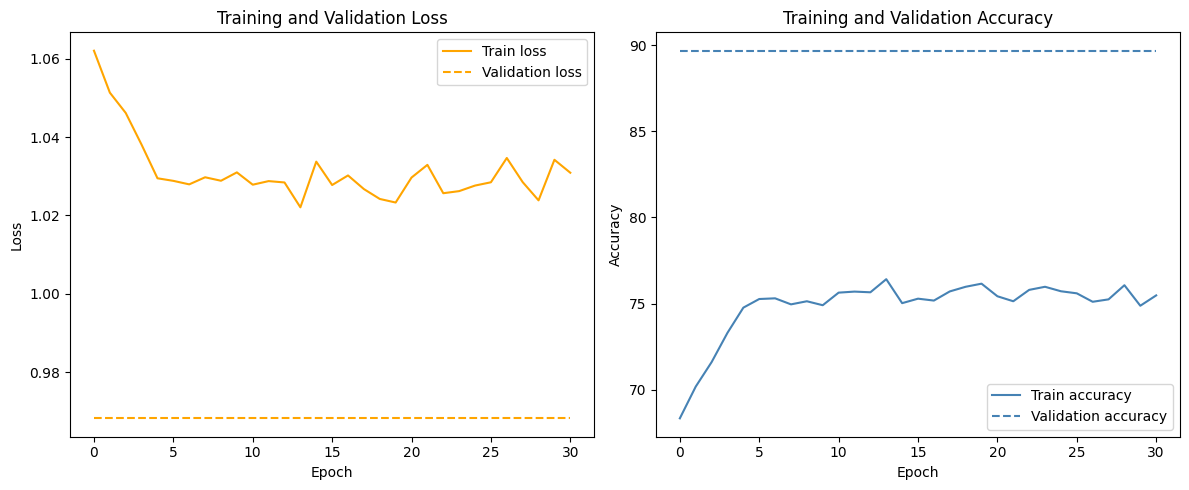

In [15]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Saving the model**

In [18]:
torch.save(model.state_dict(), 'MFCC_deepfake_audio_detection_model.pth')

**EER Calculation**

In [21]:
import numpy as np

all_scores = []
all_labels = []

model.eval()
with torch.no_grad():
    for features, labels in dev_dataLoader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        
        all_scores.extend(outputs.cpu().numpy().flatten())  # model scores (probabilities)
        all_labels.extend(labels.cpu().numpy())             # ground truth labels
non_zero_count = np.count_nonzero(all_scores)
print(f"Number of non-zero scores: {non_zero_count}")

Number of non-zero scores: 54


**Testing the model in the Test Set - NEEDS MODIFICATION TO THE NEW DATASET (THIS IS FROM DL CODING TASK)**

In [ ]:
### WILL BE MODIFIED LATER - THIS IS FROM DL CODING TASK ###

# Load test data
test_data = json.load(open('ser_test_2.json', 'r'))

# Preprocess test data
test_features = [torch.tensor(sample["features"]) for sample in test_data.values()]

# Pad the test features to the same length as the training set (1707)
target_length = 1707  # Same as training set
test_padded_features = torch.zeros(len(test_features), target_length, 26)  # Initialize with zeros

# Use the same padding value as the training data (e.g., mean_value)
for i, feature in enumerate(test_features):
    seq_length = feature.size(0)
    if seq_length <= target_length:
        # Pad with the mean value if the sequence is shorter
        test_padded_features[i, :seq_length, :] = feature
        test_padded_features[i, seq_length:, :] = mean_value  # Fill the rest with the mean value
    else:
        # Truncate if the sequence is longer
        test_padded_features[i, :, :] = feature[:target_length, :]

# Normalize the features using the training data's mean and std
#test_padded_features = (test_padded_features - mean) / std

# Create a DataLoader for the test set
test_dataset = TensorDataset(test_padded_features)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Make predictions
model.eval()  # Set model to evaluation mode
predictions_dict = {}

with torch.no_grad():
    for i, features in enumerate(test_loader):
        features = features[0].to(device)
        outputs = model(features)
        predicted = (outputs > 0.5).float().cpu().numpy()  # Convert probabilities to binary predictions
        
        # Format predictions
        for j, pred in enumerate(predicted):
            sample_id = str(i * 32 + j)  # Assuming batch size of 32
            predictions_dict[sample_id] = {
                "valence": int(pred[1]),  # Valence prediction
                "activation": int(pred[0])  # Activation prediction
            }

# Save predictions to a JSON file
with open('predictions_ultimate_model.json', 'w') as f:
    json.dump(predictions_dict, f, indent=4)

print("Predictions saved with success")

Predictions saved with success


In [15]:
unique_ids = list(test_data.keys())
print(unique_ids)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '15